In [4]:
import utility_functions as utils
import GLM
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
import numpy.matlib
sns.set_theme()

Simulate a toy system of two populations

# neuron1 -> neuron2 (only regress on neuron 2)

## One neuron

### Creating ground truth coupling filters and history filters

In [1529]:
nneuron = 1 # ten neurons in each population
nt = 1000 # Say there are 1000 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
ntrial = 500 # 5000 trials in total
npop = 2 # two populations

time_line = np.arange(nt)
log_lambda_baseline = np.log(0.3) # the baseline firing rate is 0.05 spikes/ms or 50 spikes/s
log_lambda_stimulus = 1* np.exp(-((time_line-300)/100)**2) # stimulus drives the firing rate higher around t=200ms. 

coupling_length = 30
time_line_coupling = np.arange(coupling_length)
ground_truth_coupling_filter = 0.1*time_line_coupling*np.exp(-time_line_coupling/5)

history_length = 50
time_line_history = np.arange(history_length)
ground_truth_history = -2*np.exp(-time_line_history/10)

In [1530]:
# Do simulation
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_ind_only_history = [np.zeros((nt, nneuron_list[ipop], ntrial)) for i in range(npop)]

baseline_mat = np.vstack((log_lambda_baseline + log_lambda_stimulus, log_lambda_baseline + 0.5*log_lambda_stimulus)).T
coupling_mat = np.zeros((len(ground_truth_coupling_filter), npop,npop))
coupling_mat[:,0,1] = np.flip(ground_truth_coupling_filter)
# coupling_mat[:,1,0] = np.flip(ground_truth_coupling_filter)
history_list = [ np.flip(ground_truth_history) for i in range(npop)] 
nneuron_list = [nneuron]*npop

for itrial in range(ntrial):
    pop_spikes_single_trial, log_firing_rate_pop_level_single_trial, log_firing_rate_ind_only_history_single_trial \
        = GLM.simulate_individual_history(baseline_mat, coupling_mat, history_list, 
                                          nneuron_list=nneuron_list)
    for ipop in range(npop):
        pop_spikes[ipop][:, itrial] = pop_spikes_single_trial[:, ipop]
        log_firing_rate_pop_level[ipop][:, itrial] = log_firing_rate_pop_level_single_trial[:, ipop]
        log_firing_rate_ind_only_history[ipop][:, :, itrial] = log_firing_rate_ind_only_history_single_trial[ipop]

Text(0.5, 1.0, 'log firing rate of an example trial')

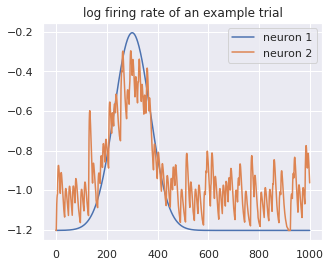

In [1531]:
itrial = 0
plt.subplots(figsize=(5,4))
plt.plot(log_firing_rate_pop_level[0][:,itrial], label='neuron 1')
plt.plot(log_firing_rate_pop_level[1][:,itrial], label='neuron 2')
plt.legend()
plt.title('log firing rate of an example trial')

### Fit GLM

In [1532]:
model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("inhomogeneous_baseline", num=10)
model.add_effect("coupling", raw_input=pop_spikes[0], num=5, peaks_max=15, nonlinear=0.2)
model.add_effect("coupling", raw_input=pop_spikes[1], num=5, peaks_max=20, nonlinear=0.2)
model.fit(target=pop_spikes[1], verbose=True)

Negative log likelihood is: 140470.45
aic/2 is: 140490.45


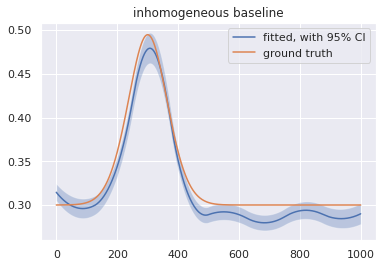

In [1533]:
GLM.plot_GLM_one_effect(model, effect_id=0, label='fitted, with 95% CI', 
                       title='inhomogeneous baseline')
plt.plot(np.exp(baseline_mat[:,1]), label="ground truth")
plt.legend()

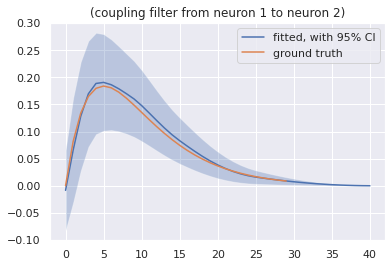

In [1534]:
GLM.plot_GLM_one_effect(model, effect_id=1, label='fitted, with 95% CI', 
                        title='(coupling filter from neuron 1 to neuron 2)')
plt.plot(ground_truth_coupling_filter, label="ground truth")
plt.legend()


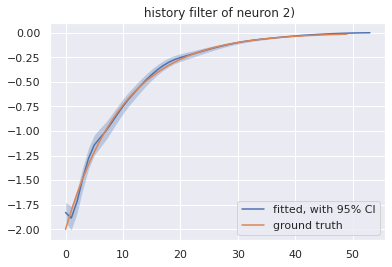

In [1535]:
GLM.plot_GLM_one_effect(model, effect_id=2, label='fitted, with 95% CI', 
                        title=' history filter of neuron 2)')
plt.plot(ground_truth_history, label="ground truth")
plt.legend()


## Ten neurons

### Creating ground truth coupling filters and history filters

In [1745]:
nneuron = 10 # ten neurons in each population
nt = 1000 # Say there are 1000 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
ntrial = 500 # 5000 trials in total
npop = 2 # two populations

time_line = np.arange(nt)
log_lambda_baseline = np.log(0.5/nneuron) # the baseline firing rate is 0.05 spikes/ms or 50 spikes/s
log_lambda_stimulus = 1* np.exp(-((time_line-300)/100)**2) # stimulus drives the firing rate higher around t=200ms. 

coupling_length = 30
time_line_coupling = np.arange(coupling_length)
ground_truth_coupling_filter = 0.1*time_line_coupling*np.exp(-time_line_coupling/5)

history_length = 50
time_line_history = np.arange(history_length)
ground_truth_history = -2*np.exp(-time_line_history/10)

In [1746]:
# Do simulation
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_ind_only_history = [np.zeros((nt, nneuron_list[ipop], ntrial)) for i in range(npop)]

baseline_mat = np.vstack((log_lambda_baseline + log_lambda_stimulus, log_lambda_baseline + 0.5*log_lambda_stimulus)).T
coupling_mat = np.zeros((len(ground_truth_coupling_filter), npop,npop))
coupling_mat[:,0,1] = np.flip(ground_truth_coupling_filter)
# coupling_mat[:,1,0] = np.flip(ground_truth_coupling_filter)
history_list = [ np.flip(ground_truth_history) for i in range(npop)] 
nneuron_list = [nneuron]*npop

for itrial in range(ntrial):
    pop_spikes_single_trial, log_firing_rate_pop_level_single_trial, log_firing_rate_ind_only_history_single_trial \
        = GLM.simulate_individual_history(baseline_mat, coupling_mat, history_list, 
                                          nneuron_list=nneuron_list)
    for ipop in range(npop):
        pop_spikes[ipop][:, itrial] = pop_spikes_single_trial[:, ipop]
        log_firing_rate_pop_level[ipop][:, itrial] = log_firing_rate_pop_level_single_trial[:, ipop]
        log_firing_rate_ind_only_history[ipop][:, :, itrial] = log_firing_rate_ind_only_history_single_trial[ipop]

Text(0.5, 1.0, 'log firing rate of an example trial')

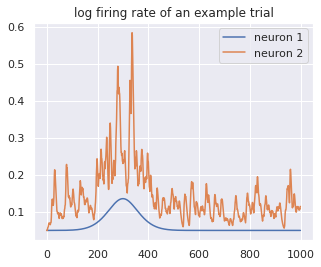

In [1747]:
itrial = 0
plt.subplots(figsize=(5,4))
plt.plot(np.exp(log_firing_rate_pop_level[0][:,itrial]), label='neuron 1')
plt.plot(np.exp(log_firing_rate_pop_level[1][:,itrial]), label='neuron 2')
plt.legend()
plt.title('log firing rate of an example trial')

In [1748]:
pop_spikes[1][500:,:].mean()

0.500392

### Fit GLM

In [1749]:
model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("inhomogeneous_baseline", num=10)
model.add_effect("coupling", raw_input=pop_spikes[0], num=10, peaks_max=20, nonlinear=0.2)
model.add_effect("coupling", raw_input=pop_spikes[1], num=10, peaks_max=32, nonlinear=0.2)
model.fit(target=pop_spikes[1], verbose=True)

Negative log likelihood is: 426178.91
aic/2 is: 426208.91


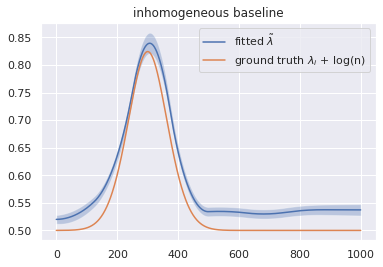

In [1750]:
GLM.plot_GLM_one_effect(model, effect_id=0, label=r'fitted $\tilde{\lambda}$ ', 
                        title=r'inhomogeneous baseline')
plt.plot(np.exp(baseline_mat[:,1]+np.log(10)), label=r"ground truth $\lambda_i$ + log(n)")
plt.legend()

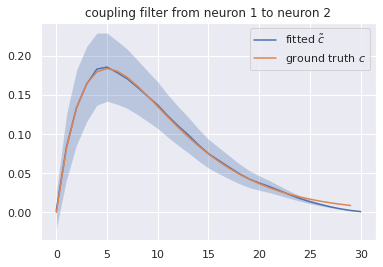

In [1751]:
GLM.plot_GLM_one_effect(model, effect_id=1, label=r'fitted $\tilde{c}$', 
                        title=r'coupling filter from neuron 1 to neuron 2')
plt.plot(ground_truth_coupling_filter, label=r"ground truth $c$")
plt.legend()

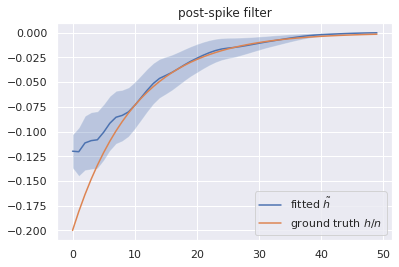

In [1752]:
GLM.plot_GLM_one_effect(model, effect_id=2, label=r'fitted $\tilde{h}$', 
                        title=r'post-spike filter')
plt.plot(ground_truth_history/nneuron, label=r"ground truth $h/n$")
plt.legend()

# Stablility dignostic

## Verify stability dignostic

########### New single pop

Text(0.5, 1.0, 'log firing rate of an example trial')

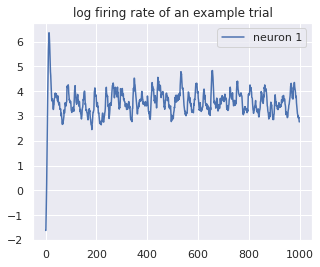

In [3075]:
nneuron = 100 # ten neurons in each population
nt = 1000 # Say there are 1000 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
ntrial = 50 # 5000 trials in total
npop = 1 # two populations
nneuron_list = [nneuron]*npop

time_line = np.arange(nt)
log_lambda_baseline = np.log(20/nneuron) # the baseline firing rate is 0.05 spikes/ms or 50 spikes/s
log_lambda_stimulus = np.log(1)* np.exp(-((time_line-300)/200)**2) # stimulus drives the firing rate higher around t=200ms. 

coupling_length = 50
time_line_coupling = np.arange(coupling_length)
ground_truth_coupling_filter = 0.025*np.exp(-time_line_coupling/10)

history_length = 50
time_line_history = np.arange(history_length)
ground_truth_history = -3*np.exp(-time_line_history/10)

# Do simulation
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_ind_only_history = [np.zeros((nt, nneuron_list[i], ntrial)) for i in range(npop)]

baseline_mat = np.vstack((log_lambda_baseline + 1*log_lambda_stimulus))
coupling_mat = np.zeros((len(ground_truth_coupling_filter), npop,npop))
coupling_mat[:,0,0] = np.flip(ground_truth_coupling_filter)
history_list = [ np.flip(ground_truth_history) for i in range(npop)] 

for itrial in range(ntrial):
    pop_spikes_single_trial, log_firing_rate_pop_level_single_trial, log_firing_rate_ind_only_history_single_trial \
        = GLM.simulate_individual_history(baseline_mat, coupling_mat, history_list, 
                                          nneuron_list=nneuron_list)
    for ipop in range(npop):
        pop_spikes[ipop][:, itrial] = pop_spikes_single_trial[:]
        log_firing_rate_pop_level[ipop][:, itrial] = log_firing_rate_pop_level_single_trial[:]
        log_firing_rate_ind_only_history[ipop][:, :, itrial] = log_firing_rate_ind_only_history_single_trial[ipop]
        
itrial = 0
plt.subplots(figsize=(5,4))
plt.plot(log_firing_rate_pop_level[0][:,itrial], label='neuron 1')
plt.legend()
plt.title('log firing rate of an example trial')

In [3076]:
# Do simulation with the new fitted model
ntrial = 50

max_coupling_length = np.max((model_list[0].basis_list[1].shape[0], model_list[0].basis_list[2].shape[0]))
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]

baseline_mat_fitted = np.vstack((log_lambda_baseline + 1*log_lambda_stimulus)) + np.log(nneuron)
coupling_mat = np.zeros((len(ground_truth_coupling_filter), npop,npop))
coupling_mat[:,0,0] = np.flip(ground_truth_coupling_filter)
coupling_mat[:,0,0] += np.flip(ground_truth_history)/nneuron

for itrial in range(ntrial):
    pop_spikes_single_trial, log_firing_rate_pop_level_single_trial \
        = GLM.simulate_baseline_coupling(baseline_mat_fitted, coupling_mat)
    for ipop in range(npop):
        pop_spikes[ipop][:, itrial] = pop_spikes_single_trial[:]
        log_firing_rate_pop_level[ipop][:, itrial] = log_firing_rate_pop_level_single_trial[:]

Text(0.5, 1.0, 'log firing rate of an example trial')

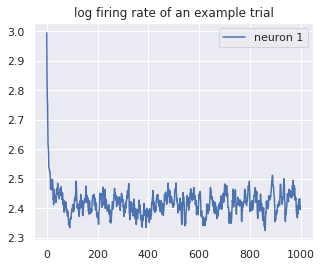

In [3077]:
itrial = 0
plt.subplots(figsize=(5,4))
plt.plot(log_firing_rate_pop_level[0][:,itrial], label='neuron 1')
plt.legend()
plt.title('log firing rate of an example trial')

############ New single pop

In [2987]:
nneuron = 30 # ten neurons in each population
nt = 1000 # Say there are 1000 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
ntrial = 50 # 5000 trials in total
npop = 2 # two populations
nneuron_list = [nneuron]*npop

time_line = np.arange(nt)
log_lambda_baseline = np.log(1/nneuron) # the baseline firing rate is 0.05 spikes/ms or 50 spikes/s
log_lambda_stimulus = np.log(1)* np.exp(-((time_line-300)/200)**2) # stimulus drives the firing rate higher around t=200ms. 

coupling_length = 50
time_line_coupling = np.arange(coupling_length)
ground_truth_coupling_filter = 0.15*np.exp(-time_line_coupling/5)

history_length = 50
time_line_history = np.arange(history_length)
ground_truth_history = -5*np.exp(-time_line_history/5)

In [2988]:
# Do simulation
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_ind_only_history = [np.zeros((nt, nneuron_list[ipop], ntrial)) for i in range(npop)]

baseline_mat = np.vstack((log_lambda_baseline + 1*log_lambda_stimulus, log_lambda_baseline + 1*log_lambda_stimulus)).T
coupling_mat = np.zeros((len(ground_truth_coupling_filter), npop,npop))
coupling_mat[:,0,1] = np.flip(ground_truth_coupling_filter)
coupling_mat[:,1,0] = np.flip(ground_truth_coupling_filter)
history_list = [ np.flip(ground_truth_history) for i in range(npop)] 

for itrial in range(ntrial):
    pop_spikes_single_trial, log_firing_rate_pop_level_single_trial, log_firing_rate_ind_only_history_single_trial \
        = GLM.simulate_individual_history(baseline_mat, coupling_mat, history_list, 
                                          nneuron_list=nneuron_list)
    for ipop in range(npop):
        pop_spikes[ipop][:, itrial] = pop_spikes_single_trial[:, ipop]
        log_firing_rate_pop_level[ipop][:, itrial] = log_firing_rate_pop_level_single_trial[:, ipop]
        log_firing_rate_ind_only_history[ipop][:, :, itrial] = log_firing_rate_ind_only_history_single_trial[ipop]

Text(0.5, 1.0, 'log firing rate of an example trial')

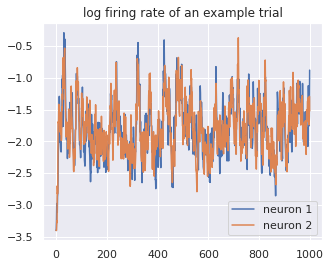

In [2989]:
itrial = 0
plt.subplots(figsize=(5,4))
plt.plot(log_firing_rate_pop_level[0][:,itrial], label='neuron 1')
plt.plot(log_firing_rate_pop_level[1][:,itrial], label='neuron 2')
plt.legend()
plt.title('log firing rate of an example trial')

Therefore, the system is stable without pooling. 

In [2978]:
model_list = []

model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("inhomogeneous_baseline", num=10)
model.add_effect("coupling", raw_input=pop_spikes[0], num=10, peaks_max=32, nonlinear=0.2)
model.add_effect("coupling", raw_input=pop_spikes[1], num=10, peaks_max=32, nonlinear=0.2)
model.fit(target=pop_spikes[1], verbose=True)
model_list.append(model)

model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("inhomogeneous_baseline", num=10)
model.add_effect("coupling", raw_input=pop_spikes[1], num=10, peaks_max=32, nonlinear=0.2)
model.add_effect("coupling", raw_input=pop_spikes[0], num=10, peaks_max=32, nonlinear=0.2)
model.fit(target=pop_spikes[0], verbose=True)
model_list.append(model)

/home/qix/MultiNeuronGLM/GLM.py:1036: RuntimeWarning: overflow encountered in exp
  nll += np.exp(log_lmbd)


Negative log likelihood is: -552793087.61
aic/2 is: -552793057.61
Negative log likelihood is: -553075626.98
aic/2 is: -553075596.98


In [2979]:
model_list[0].get_filter()[1].sum(), model_list[0].get_filter()[2].sum()

(0.00856581571544214, -0.006550562486225938)

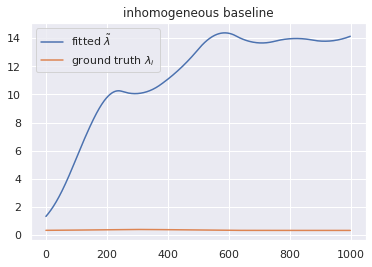

In [2980]:
GLM.plot_GLM_one_effect(model_list[0], effect_id=0, label=r'fitted $\tilde{\lambda}$ ', 
                        title=r'inhomogeneous baseline')
plt.plot(np.exp(baseline_mat[:,1]+np.log(10)), label=r"ground truth $\lambda_i$")
plt.legend()

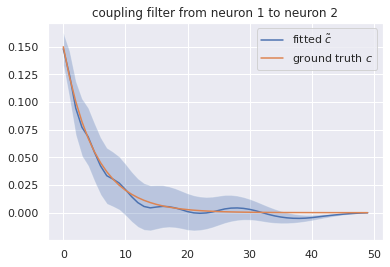

In [2954]:
GLM.plot_GLM_one_effect(model, effect_id=1, label=r'fitted $\tilde{c}$', 
                        title=r'coupling filter from neuron 1 to neuron 2')
plt.plot(ground_truth_coupling_filter, label=r"ground truth $c$")
plt.legend()

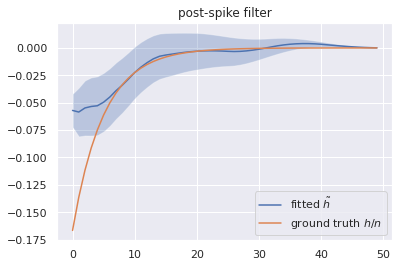

In [2955]:
GLM.plot_GLM_one_effect(model, effect_id=2, label=r'fitted $\tilde{h}$', 
                        title=r'post-spike filter')
plt.plot(ground_truth_history/nneuron, label=r"ground truth $h/n$")
plt.legend()

In [2956]:
# Do simulation with the new fitted model
ntrial = 50

max_coupling_length = np.max((model_list[0].basis_list[1].shape[0], model_list[0].basis_list[2].shape[0]))
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]

baseline_mat_fitted = np.vstack((model_list[0].get_filter()[0], model_list[1].get_filter()[0])).T
# baseline_mat_fitted = np.log(10) + baseline_mat
coupling_mat = np.zeros((max_coupling_length, npop,npop), dtype=float)

to_add = model_list[0].get_filter()[1]
to_add_length = to_add.shape[0]
coupling_mat[-to_add_length:,0,1] = np.flip(to_add)

to_add = model_list[1].get_filter()[1]
to_add_length = to_add.shape[0]
coupling_mat[-to_add_length:,1,0] = np.flip(to_add)

to_add = model_list[0].get_filter()[2]
to_add_length = to_add.shape[0]
coupling_mat[-to_add_length:,1,1] = np.flip(to_add)

to_add = model_list[1].get_filter()[2]
to_add_length = to_add.shape[0]
coupling_mat[-to_add_length:,0,0] = np.flip(to_add)
nneuron_list = [1]*npop

for itrial in range(ntrial):
    pop_spikes_single_trial, log_firing_rate_pop_level_single_trial \
        = GLM.simulate_baseline_coupling(baseline_mat_fitted, coupling_mat)
    for ipop in range(npop):
        pop_spikes[ipop][:, itrial] = pop_spikes_single_trial[:, ipop]
        log_firing_rate_pop_level[ipop][:, itrial] = log_firing_rate_pop_level_single_trial[:, ipop]

ValueError: lam value too large

In [2957]:
model_list[0].get_filter()[1].sum(), model_list[0].get_filter()[2].sum()

(0.7686888919823038, -0.5478470203666301)

Text(0.5, 1.0, 'log firing rate of an example trial')

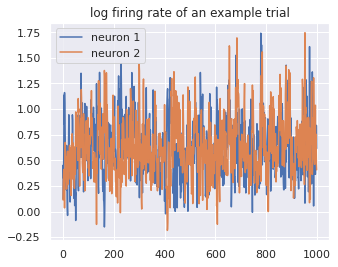

In [2958]:
itrial = 0
plt.subplots(figsize=(5,4))
plt.plot(log_firing_rate_pop_level[0][:,itrial], label='neuron 1')
plt.plot(log_firing_rate_pop_level[1][:,itrial], label='neuron 2')
plt.legend()
plt.title('log firing rate of an example trial')

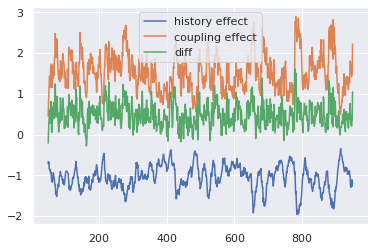

In [2959]:
itrial = 0
t_list = np.arange(50,950)
history_effect_rcd = np.zeros_like(t_list, dtype=float)
coupling_effect_rcd = np.zeros_like(t_list, dtype=float)
for i, t in enumerate(t_list):
    history_effect_rcd[i] = (pop_spikes[0][t-50:t, itrial]*coupling_mat[:,1,1]).sum()
    coupling_effect_rcd[i] = (pop_spikes[1][t-50:t, itrial]*coupling_mat[:,0,1]).sum()
plt.plot(t_list, history_effect_rcd, label='history effect')
plt.plot(t_list, coupling_effect_rcd, label='coupling effect')
plt.plot(t_list, coupling_effect_rcd+history_effect_rcd, label='diff')
plt.legend()

In [2960]:
coupling_mat[:,0,1].sum()

0.7686888919823037

In [2961]:
coupling_mat[:,1,1].sum()

-0.5478470203666302

In [2962]:
pop_spikes[0][:, itrial].sum()

1912.0

In [2963]:
pop_spikes[1][:, itrial].sum()

1989.0

In [2966]:
# Simulate the system of baseline=baseline+log(10) and h=h/10
nneuron = 43
ntrial = 50

max_coupling_length = np.max((model_list[0].basis_list[1].shape[0], model_list[0].basis_list[2].shape[0]))
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]

baseline_mat_fitted = np.log(nneuron) + np.vstack((log_lambda_baseline + log_lambda_stimulus, log_lambda_baseline + 0.5*log_lambda_stimulus)).T
coupling_mat = np.zeros((max_coupling_length, npop,npop))

to_add = ground_truth_coupling_filter
to_add_length = to_add.shape[0]
coupling_mat[-to_add_length:,0,1] = np.flip(to_add)

to_add = ground_truth_coupling_filter
to_add_length = to_add.shape[0]
coupling_mat[-to_add_length:,1,0] = np.flip(to_add)

# to_add = ground_truth_history/nneuron
to_add = model_list[0].get_filter()[2]
to_add_length = to_add.shape[0]
coupling_mat[-to_add_length:,1,1] = np.flip(to_add)

# to_add = ground_truth_history/nneuron
to_add = model_list[1].get_filter()[2]
to_add_length = to_add.shape[0]
coupling_mat[-to_add_length:,0,0] = np.flip(to_add)
nneuron_list = [1]*npop

for itrial in range(ntrial):
    pop_spikes_single_trial, log_firing_rate_pop_level_single_trial \
        = GLM.simulate_baseline_coupling(baseline_mat_fitted, coupling_mat)
    for ipop in range(npop):
        pop_spikes[ipop][:, itrial] = pop_spikes_single_trial[:, ipop]
        log_firing_rate_pop_level[ipop][:, itrial] = log_firing_rate_pop_level_single_trial[:, ipop]

ValueError: lam value too large

Text(0.5, 1.0, 'log firing rate of an example trial')

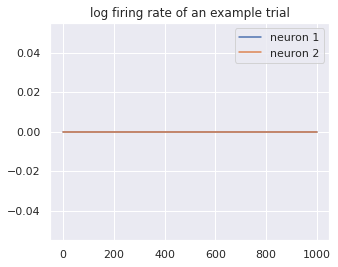

In [2967]:
itrial = 0
plt.subplots(figsize=(5,4))
plt.plot(log_firing_rate_pop_level[0][:,itrial], label='neuron 1')
plt.plot(log_firing_rate_pop_level[1][:,itrial], label='neuron 2')
plt.legend()
plt.title('log firing rate of an example trial')

## Stability dignostic

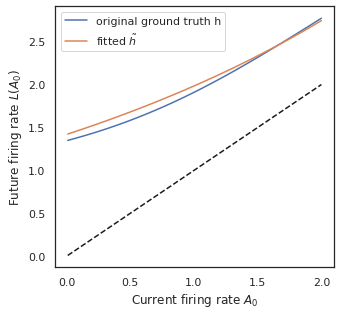

In [2968]:
def L_ind(A0, nneuron, c, h, beta0):
    ndt = 1
    LA0 = L_ind_varying_dt(A0, nneuron, c, h, beta0, 1)
    while True:
        LA0 = L_ind_varying_dt(A0, nneuron, c, h, beta0, ndt)
        if LA0 is not None:
            break
        ndt *= 10
    return LA0
    
def L_ind_varying_dt(A0, nneuron, c, h, beta0, ndt):
    A0_ind = A0/nneuron
    survive = 1
    meanISI = 0
    for i in range(len(h)):
        log_lambda = beta0
        log_lambda += (A0*c).sum()
        log_lambda += h[i]
        log_lambda += (A0_ind*h[i+1:]).sum()
        firing_rate = np.exp(log_lambda)
        for idt in range(ndt):
            p = survive*firing_rate/ndt
            if p>=0.01:
                return None
            survive -= p
            meanISI += p*(i+idt/ndt)
            if survive<=1e-6:
                return nneuron/meanISI
            
    log_lambda = beta0
    log_lambda += (A0*c).sum()
    firing_rate = np.exp(log_lambda)
    while survive>1e-6:
        p = survive*firing_rate/ndt
        survive -= p
        meanISI += p*(i+1)
    return nneuron/meanISI

def L_pop(A0, nneuron, c, h, beta0):
    ndt = 1
    LA0 = L_ind_varying_dt(A0, nneuron, c, h, beta0, 1)
    while True:
        LA0 = L_pop_varying_dt(A0, nneuron, c, h, beta0, ndt)
        if LA0 is not None:
            break
        ndt *= 10
    return LA0
    
def L_pop_varying_dt(A0, nneuron, c, h, beta0, ndt):
    survive = 1
    meanISI = 0
    for i in range(len(h)):
        log_lambda = beta0
        log_lambda += (A0*c).sum()
        log_lambda += h[i]
        log_lambda += (A0*h[i+1:]).sum()
        firing_rate = np.exp(log_lambda)
        for idt in range(ndt):
            p = survive*firing_rate/ndt
            if p>=0.01:
                return None
            survive -= p
            meanISI += p*(i+idt/ndt)
            if survive<=1e-6:
                return 1/meanISI
#         print(f"got here! i={i}")
    log_lambda = beta0
    log_lambda += (A0*c).sum()
    firing_rate = np.exp(log_lambda)
    while survive>1e-6:
        p = survive*firing_rate/ndt
        survive -= p
        meanISI += p*(i+1)
    return 1/meanISI

A0_list = np.linspace(0.01, 2, 100)
LA0_ind = np.zeros_like(A0_list)
LA0_pop = np.zeros_like(A0_list)
for i, A0 in enumerate(A0_list):
    LA0_ind[i] = L_ind(A0, nneuron, ground_truth_coupling_filter, ground_truth_history, np.log(1.5/nneuron))
    LA0_pop[i] = L_pop(A0, nneuron, ground_truth_coupling_filter, model.get_filter()[2], np.log(1.5))
#     LA0_pop[i] = L_pop(A0, nneuron, ground_truth_coupling_filter, ground_truth_history/nneuron, np.log(0.55))

sns.set_style("white")
plt.subplots(figsize=(5,4.8))
plt.plot(A0_list, A0_list, 'k--')
plt.plot(A0_list, LA0_ind, label=r"original ground truth h")
plt.plot(A0_list, LA0_pop, label=r"fitted $\tilde{h}$")
plt.xlabel("Current firing rate $A_0$")
plt.ylabel("Future firing rate $L(A_0)$")
plt.legend()
sns.set_theme()

# neuron1 <--> neuron2 (regress both neuron and do simulation)

## Ten neurons

### Creating ground truth coupling filters and history filters

In [1681]:
nneuron = 10 # ten neurons in each population
nt = 1000 # Say there are 1000 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
ntrial = 500 # 5000 trials in total
npop = 2 # two populations

time_line = np.arange(nt)
log_lambda_baseline = np.log(0.5/nneuron) # the baseline firing rate is 0.05 spikes/ms or 50 spikes/s
log_lambda_stimulus = 0* np.exp(-((time_line-300)/100)**2) # stimulus drives the firing rate higher around t=200ms. 

coupling_length = 30
time_line_coupling = np.arange(coupling_length)
ground_truth_coupling_filter = 0.1*time_line_coupling*np.exp(-time_line_coupling/5)

history_length = 50
time_line_history = np.arange(history_length)
ground_truth_history = -2.5*np.exp(-time_line_history/10)

In [1682]:
# Do simulation
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_ind_only_history = [np.zeros((nt, nneuron_list[ipop], ntrial)) for i in range(npop)]

baseline_mat = np.vstack((log_lambda_baseline + log_lambda_stimulus, log_lambda_baseline + 0.5*log_lambda_stimulus)).T
coupling_mat = np.zeros((len(ground_truth_coupling_filter), npop,npop))
coupling_mat[:,0,1] = np.flip(ground_truth_coupling_filter)
coupling_mat[:,1,0] = np.flip(ground_truth_coupling_filter)
history_list = [ np.flip(ground_truth_history) for i in range(npop)] 
nneuron_list = [nneuron]*npop

for itrial in range(ntrial):
    pop_spikes_single_trial, log_firing_rate_pop_level_single_trial, log_firing_rate_ind_only_history_single_trial \
        = GLM.simulate_individual_history(baseline_mat, coupling_mat, history_list, 
                                          nneuron_list=nneuron_list)
    for ipop in range(npop):
        pop_spikes[ipop][:, itrial] = pop_spikes_single_trial[:, ipop]
        log_firing_rate_pop_level[ipop][:, itrial] = log_firing_rate_pop_level_single_trial[:, ipop]
        log_firing_rate_ind_only_history[ipop][:, :, itrial] = log_firing_rate_ind_only_history_single_trial[ipop]

Text(0.5, 1.0, 'log firing rate of an example trial')

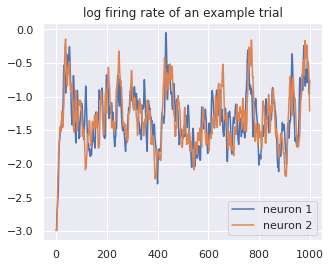

In [1683]:
itrial = 0
plt.subplots(figsize=(5,4))
plt.plot(log_firing_rate_pop_level[0][:,itrial], label='neuron 1')
plt.plot(log_firing_rate_pop_level[1][:,itrial], label='neuron 2')
plt.legend()
plt.title('log firing rate of an example trial')

In [1684]:
pop_spikes[0][280:320,:].mean()

0.7082

### Fit GLM

In [1685]:
model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("inhomogeneous_baseline", num=10)
model.add_effect("coupling", raw_input=pop_spikes[0], num=10, peaks_max=20, nonlinear=0.2)
model.add_effect("coupling", raw_input=pop_spikes[1], num=10, peaks_max=32, nonlinear=0.2)
model.fit(target=pop_spikes[1], verbose=True)

Negative log likelihood is: 458333.73
aic/2 is: 458363.73


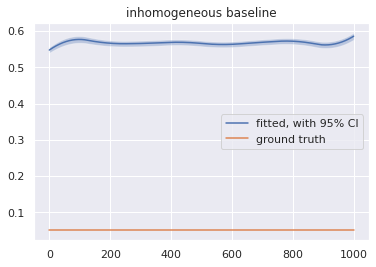

In [1686]:
GLM.plot_GLM_one_effect(model, effect_id=0, label='fitted, with 95% CI', 
                       title='inhomogeneous baseline')
plt.plot(np.exp(baseline_mat[:,1]), label="ground truth")
plt.legend()

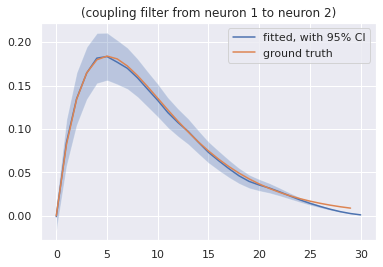

In [1689]:
GLM.plot_GLM_one_effect(model, effect_id=1, label='fitted, with 95% CI', 
                        title='(coupling filter from neuron 1 to neuron 2)')
plt.plot(ground_truth_coupling_filter, label="ground truth")
plt.legend()


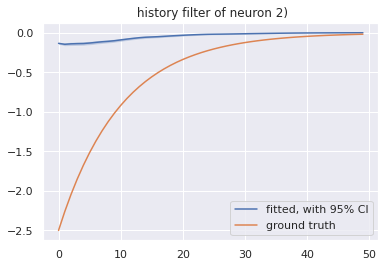

In [1688]:
GLM.plot_GLM_one_effect(model, effect_id=2, label='fitted, with 95% CI', 
                        title=' history filter of neuron 2)')
plt.plot(ground_truth_history, label="ground truth")
plt.legend()
# plt.ylim([-3.5,0])
# plt.xlim([0,30])

# Reproducing explosion 

## Without considering history

In [1004]:
# Creating ground truth coupling filters and history filters
nneuron = 10 # ten neurons in each population
nt = 1000 # Say there are 1000 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
ntrial = 500 # 5000 trials in total
npop = 2 # two populations

time_line = np.arange(nt)
log_lambda_baseline = np.log(0.5/nneuron) # the baseline firing rate is 0.05 spikes/ms or 50 spikes/s
log_lambda_stimulus = 1* np.exp(-((time_line-300)/100)**2) # stimulus drives the firing rate higher around t=200ms. 

coupling_length = 30
time_line_coupling = np.arange(coupling_length)
ground_truth_coupling_filter = 0.1*time_line_coupling*np.exp(-time_line_coupling/5)

history_length = 50
time_line_history = np.arange(history_length)
ground_truth_history = -2*np.exp(-time_line_history/10)

In [1005]:
# Do simulation
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]

baseline_mat = np.vstack((log_lambda_baseline + log_lambda_stimulus, log_lambda_baseline + 0.5*log_lambda_stimulus)).T
coupling_mat = np.zeros((len(ground_truth_coupling_filter), npop,npop))
coupling_mat[:,0,1] = np.flip(ground_truth_coupling_filter)
coupling_mat[:,1,0] = np.flip(ground_truth_coupling_filter)
history_list = [ np.flip(ground_truth_history) for i in range(npop)] 
nneuron_list = [nneuron]*npop

for itrial in range(ntrial):
    
    pop_spikes_single_trial, log_firing_rate_pop_level_single_trial = GLM.simulate_individual_history(baseline_mat, 
                                                                            coupling_mat, 
                                                                            history_list, 
                                                                            nneuron_list=nneuron_list)
    for ipop in range(npop):
        pop_spikes[ipop][:, itrial] = pop_spikes_single_trial[:, ipop]
        log_firing_rate_pop_level[ipop][:, itrial] = log_firing_rate_pop_level_single_trial[:, ipop]

ValueError: too many values to unpack (expected 2)

In [1006]:
model_list = []

model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("inhomogeneous_baseline", num=10)
model.add_effect("coupling", raw_input=pop_spikes[0], num=5, peaks_max=15, nonlinear=0.2)
# model.add_effect("coupling", raw_input=pop_spikes[1], num=5, peaks_max=10, nonlinear=0.2)
model.fit(target=pop_spikes[1], verbose=True)
model_list.append(model)

model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("inhomogeneous_baseline", num=10)
# model.add_effect("coupling", raw_input=pop_spikes[0], num=5, peaks_max=15, nonlinear=0.2)
model.add_effect("coupling", raw_input=pop_spikes[1], num=5, peaks_max=10, nonlinear=0.2)
model.fit(target=pop_spikes[0], verbose=True)
model_list.append(model)

Negative log likelihood is: 0.00
aic/2 is: 15.00
Negative log likelihood is: 0.00
aic/2 is: 15.00


In [1007]:
# Do simulation
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]

baseline_mat = np.vstack((model_list[0].get_filter()[0], model_list[1].get_filter()[0])).T
coupling_mat = np.zeros((model_list[0].basis_list[1].shape[1], npop,npop))
coupling_mat[:,0,1] = np.flip(model_list[0].get_filter()[1].shape)
coupling_mat[:,1,0] = np.flip(model_list[1].get_filter()[1].shape)
# history_list = [ np.flip(ground_truth_history) for i in range(npop)] 
# nneuron_list = [nneuron]*npop

for itrial in range(ntrial):
    GLM.simulate_baseline_coupling(baseline_mat, coupling_mat)
    for ipop in range(npop):
        pop_spikes[ipop][:, itrial] = pop_spikes_single_trial[:, ipop]
        log_firing_rate_pop_level[ipop][:, itrial] = log_firing_rate_pop_level_single_trial[:, ipop]

## Considering history

In [1695]:
# Creating ground truth coupling filters and history filters
nneuron = 10 # ten neurons in each population
nt = 1000 # Say there are 1000 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
ntrial = 500 # 5000 trials in total
npop = 2 # two populations

time_line = np.arange(nt)
log_lambda_baseline = np.log(0.5/nneuron) # the baseline firing rate is 0.05 spikes/ms or 50 spikes/s
log_lambda_stimulus = 0* np.exp(-((time_line-300)/100)**2) # stimulus drives the firing rate higher around t=200ms. 

coupling_length = 30
time_line_coupling = np.arange(coupling_length)
ground_truth_coupling_filter = 0.1*time_line_coupling*np.exp(-time_line_coupling/5)

history_length = 50
time_line_history = np.arange(history_length)
ground_truth_history = -2*np.exp(-time_line_history/10)

In [1696]:
# Do simulation
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]

baseline_mat = np.vstack((log_lambda_baseline + log_lambda_stimulus, log_lambda_baseline + 0.5*log_lambda_stimulus)).T
coupling_mat = np.zeros((len(ground_truth_coupling_filter), npop,npop))
coupling_mat[:,0,1] = np.flip(ground_truth_coupling_filter)
coupling_mat[:,1,0] = np.flip(ground_truth_coupling_filter)
history_list = [ np.flip(ground_truth_history) for i in range(npop)] 
nneuron_list = [nneuron]*npop

for itrial in range(ntrial):
    
    pop_spikes_single_trial, log_firing_rate_pop_level_single_trial = GLM.simulate_individual_history(baseline_mat, 
                                                                            coupling_mat, 
                                                                            history_list, 
                                                                            nneuron_list=nneuron_list)
    for ipop in range(npop):
        pop_spikes[ipop][:, itrial] = pop_spikes_single_trial[:, ipop]
        log_firing_rate_pop_level[ipop][:, itrial] = log_firing_rate_pop_level_single_trial[:, ipop]

ValueError: too many values to unpack (expected 2)

In [1692]:
model_list = []

model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("inhomogeneous_baseline", num=10)
model.add_effect("coupling", raw_input=pop_spikes[0], num=5, peaks_max=15, nonlinear=0.2)
model.add_effect("coupling", raw_input=pop_spikes[1], num=5, peaks_max=10, nonlinear=0.2)
model.fit(target=pop_spikes[1], verbose=True)
model_list.append(model)

model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("inhomogeneous_baseline", num=10)
model.add_effect("coupling", raw_input=pop_spikes[1], num=5, peaks_max=15, nonlinear=0.2)
model.add_effect("coupling", raw_input=pop_spikes[0], num=5, peaks_max=10, nonlinear=0.2)
model.fit(target=pop_spikes[0], verbose=True)
model_list.append(model)

Negative log likelihood is: 0.00
aic/2 is: 20.00
Negative log likelihood is: 0.00
aic/2 is: 20.00


In [1693]:
# Do simulation
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]

baseline_mat = np.vstack((model_list[0].get_filter()[0], model_list[1].get_filter()[0])).T
coupling_mat = np.zeros((model_list[0].basis_list[1].shape[1], npop,npop))
coupling_mat[:,0,1] = np.flip(model_list[0].get_filter()[1].shape)
coupling_mat[:,1,0] = np.flip(model_list[1].get_filter()[1].shape)
history_list = [ model_list[i].get_filter()[2] for i in range(npop)] 
nneuron_list = [1]*npop

for itrial in range(ntrial):
    GLM.simulate_baseline_coupling(baseline_mat, coupling_mat)
    for ipop in range(npop):
        pop_spikes[ipop][:, itrial] = pop_spikes_single_trial[:, ipop]
        log_firing_rate_pop_level[ipop][:, itrial] = log_firing_rate_pop_level_single_trial[:, ipop]

In [1694]:
# Do simulation
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]

baseline_mat = np.vstack((model_list[0].get_filter()[0], model_list[1].get_filter()[0])).T
coupling_mat = np.zeros((model_list[0].basis_list[1].shape[1], npop,npop))
coupling_mat[:,0,1] = np.flip(model_list[0].get_filter()[1].shape)
coupling_mat[:,1,0] = np.flip(model_list[1].get_filter()[1].shape)
history_list = [ model_list[i].get_filter()[2] for i in range(npop)] 
nneuron_list = [1]*npop

temp = copy.deepcopy(history_list)
history_list = temp
max_histories_history = 0
if nneuron_list is not None:
    assert len(history_list) == len(nneuron_list), "The number of populations should matach!"
    for i, history in enumerate(history_list):
        assert history_list[i].ndim == 1
        history_list[i] = np.matlib.repmat(history, nneuron_list[i], 1).T
        max_histories_history = max(max_histories_history, history.shape[0])
else:
    for i, history in enumerate(history_list):
        nneuron_list[i] = history.shape[1]
        max_histories_history = max(max_histories_history, history.shape[0])

max_histories_coupling, _, npop = coupling_mat.shape
nt = baseline_mat.shape[0]
pop_spikes = np.zeros((nt, npop, 1))
ind_spikes = [np.zeros((nt, nneuron_list[i])) for i in range(npop)]
log_firing_rate_pop_level = copy.deepcopy(baseline_mat[:,:,np.newaxis])  # np.newaxis doesn't create a new data array!!!
# t=0
for ipop in range(npop):
    log_firing_rate_ind = log_firing_rate_pop_level[0, ipop, 0]*np.ones(nneuron_list[ipop]) \
                        - np.log(nneuron_list[i])
    log_firing_rate_ind_only_history = 0
    log_firing_rate_ind += log_firing_rate_ind_only_history
    ind_spikes[ipop][0, :] = np.random.poisson(np.exp(log_firing_rate_ind))
    pop_spikes[0,ipop,0] = np.sum(ind_spikes[ipop][0, :])

for t in range(1, nt):
    nhistories = min(t, max_histories_coupling)
    log_firing_rate_coupling = (coupling_mat[-nhistories:, :, :] * pop_spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
    log_firing_rate_pop_level[t,:,0] += log_firing_rate_coupling
    for ipop in range(npop):
        log_firing_rate_ind = log_firing_rate_pop_level[t, ipop, 0]*np.ones(nneuron_list[ipop]) \
                            - np.log(nneuron_list[ipop])
        nhistories = min(t, max_histories_history)
        log_firing_rate_ind_only_history = (history_list[ipop][-nhistories:,:] * ind_spikes[ipop][(t-nhistories):(t), :]).sum(axis=0)
        log_firing_rate_ind += log_firing_rate_ind_only_history
        ind_spikes[ipop][t, :] = np.random.poisson(np.exp(log_firing_rate_ind))
        pop_spikes[t,ipop,0] = np.sum(ind_spikes[ipop][t, :])

return pop_spikes.squeeze(), log_firing_rate_pop_level.squeeze()

SyntaxError: 'return' outside function (1453145630.py, line 53)

In [763]:
log_firing_rate_pop_level[:7,:,0]

array([[-1.20167810e+00, -1.22397221e+00],
       [-1.20016418e+00, -1.21991624e+00],
       [-1.19866357e+00, -1.21589196e+00],
       [-1.19717626e+00, -1.21189939e+00],
       [-1.19570225e+00, -1.20793852e+00],
       [ 3.98057585e+01,  3.97959906e+01],
       [ 7.85901587e+18,  7.93590807e+18]])

In [762]:
t

6